# 问题二升级版：Enhanced Dynamic Model for `FILT. NTU`

本 notebook 对应 A 题第二问的升级版本。

第二问的核心目标是建立动态数学模型，描述：

```text
R/W NTU, R/W PH, ALUM, F/RIDE, R/W FLOW
```

等输入变量对滤后水浊度：

```text
FILT. NTU
```

的动态影响，并给出不同变量的时滞参数、模型估计结果和拟合精度。

原始第一版做法是：

```text
每个变量只选择一个 best lag
```

但这种 selected-one-lag 模型可能丢失动态过程信息。因此本 notebook 将其升级为：

```text
Enhanced Dynamic Feature Model
```

主要 enhancement：

```text
1. 加入 FILT. NTU 自身历史项，刻画滤后水浊度动态惯性；
2. 对核心输入变量构造 lag window，而不是每个变量只保留一个 lag；
3. 加入 rolling mean / max / std，刻画短期累计效应和波动性；
4. 构造 Core 和 Enhanced 两套特征集进行对比；
5. 同时训练 Ridge / GAM / Random Forest / XGBoost；
6. 输出模型指标、特征重要性、Ridge 参数、预测图、残差图。
```

输出目录：

```text
outputs/problem2_enhanced/
```


## 1. 导入依赖库

本 notebook 不使用大规模 GridSearch，也不使用 SHAP。  
目标是先验证特征结构增强是否能显著改善 P2 的 RMSE 和 R²。


In [1]:
from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    XGB_IMPORT_ERROR = e

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

print("XGBoost available:", XGB_AVAILABLE)
if not XGB_AVAILABLE:
    print("XGBoost import error:", XGB_IMPORT_ERROR)


XGBoost available: True


## 2. 参数设置

目标变量：

```text
FILT. NTU
```

核心输入变量：

```text
R/W NTU
R/W PH
ALUM
F/RIDE
R/W FLOW
```

增强辅助变量：

```text
RIVER LEVEL
R/W CLR
R/W PUMP COUNT
```

时滞解释：

```text
lag1 = 2 小时前
lag3 = 6 小时前
lag6 = 12 小时前
```


In [2]:
# =========================
# 基础设置
# =========================

TARGET_COL = "FILT. NTU"
OUTPUT_DIR_NAME = "problem2_enhanced"

RANDOM_STATE = 42

# 时间顺序划分比例
TRAIN_RATIO = 0.70
TEST_RATIO = 0.30

# lag 设置
CORE_LAG_WINDOW = list(range(0, 7))      # lag0-lag6，当前至过去 12 小时
ALUM_LAG_WINDOW = list(range(1, 7))      # ALUM 使用 lag1-lag6，避免过度强调即时影响
TARGET_AR_LAGS = [1, 2, 3]              # FILT. NTU 自回归项，过去 2/4/6 小时

# rolling window
ROLL_WINDOWS = [3, 6]                   # 3点=6小时，6点=12小时

# 是否对 FILT. NTU clipping
# 第二题默认不 clipping，因为要拟合真实滤后水浊度。
CLIP_TARGET = False
TARGET_CLIP_UPPER = 2.0

# 核心变量
CORE_EXOGENOUS_VARS = [
    "R/W NTU",
    "R/W PH",
    "ALUM",
    "F/RIDE",
    "R/W FLOW",
]

# 增强辅助变量
AUXILIARY_VARS = [
    "RIVER LEVEL",
    "R/W CLR",
    "R/W PUMP COUNT",
]

print("参数设置完成。")


参数设置完成。


## 3. 自动定位 `merged.xlsx`

本 notebook 从原始合并数据 `merged.xlsx` 读取，不依赖前面 P2 生成的 selected-lag 文件。  
这样可以避免覆盖旧结果，也方便独立复现。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []
    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    # 最后递归搜索
    for p in cwd.rglob(filename):
        return p.resolve()

    for parent in cwd.parents:
        for p in parent.rglob(filename):
            return p.resolve()

    searched = "\n".join(str(p) for p in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
使用数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced


## 4. 读取数据并构造时间列

构造：

```text
DATETIME
OP_DATE
```

其中 `OP_DATE` 沿用运行日定义：

```text
07:00 至次日 05:00 归为同一个运行日
```


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标变量 {TARGET_COL}。请检查 merged.xlsx。")


def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce",
    )

    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7
df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(12))


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00


,DATETIME,OP_DATE,FILT. NTU
0,2025-01-01 07:00:00,2025-01-01,0.04
1,2025-01-01 09:00:00,2025-01-01,0.05
2,2025-01-01 11:00:00,2025-01-01,0.05
3,2025-01-01 13:00:00,2025-01-01,0.05
4,2025-01-01 15:00:00,2025-01-01,0.05
5,2025-01-01 17:00:00,2025-01-01,0.06
6,2025-01-01 19:00:00,2025-01-01,0.05
7,2025-01-01 21:00:00,2025-01-01,0.05
8,2025-01-01 23:00:00,2025-01-01,0.05
9,2025-01-02 01:00:00,2025-01-01,0.05


## 5. 数据清洗与泵运行状态转换

处理内容：

```text
1. 将数值列转为 numeric；
2. F/RIDE 缺失填 0；
3. R/W PUMP DUTY 转换为 R/W PUMP COUNT；
4. 可选 target clipping，默认不启用。
```

说明：

```text
F/RIDE 缺失填 0 是沿用前面数据处理逻辑；
P2 的风险不是基于 F/RIDE 判断，因此这里主要作为模型输入变量。
```


In [5]:
def pump_duty_to_count(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s == "":
        return np.nan

    if s.endswith(".0"):
        s = s.replace(".0", "")

    if "+" in s:
        parts = [p.strip() for p in s.split("+") if p.strip() != ""]
        return len(parts)

    if s.isdigit():
        return 1

    return np.nan


# 转换泵运行状态
if "R/W PUMP DUTY" in df.columns:
    df["R/W PUMP COUNT"] = df["R/W PUMP DUTY"].apply(pump_duty_to_count)
    print("已生成 R/W PUMP COUNT。")
else:
    print("未找到 R/W PUMP DUTY，跳过 R/W PUMP COUNT。")

# 数值化
non_numeric_cols = {
    "DATE", "Date", "date",
    "TIME", "Time", "time",
    "DATETIME", "OP_DATE",
    "REMARKS",
    "R/W PUMP DUTY",
    "T/W PUMP DUTY",
}

for col in df.columns:
    if col not in non_numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# F/RIDE 缺失填 0
if "F/RIDE" in df.columns:
    before = int(df["F/RIDE"].isna().sum())
    df["F/RIDE"] = df["F/RIDE"].fillna(0)
    after = int(df["F/RIDE"].isna().sum())
    print(f"F/RIDE 缺失填 0：before={before}, after={after}")

# target clipping，默认关闭
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

if CLIP_TARGET:
    before_above = int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum())
    df[TARGET_COL] = df[TARGET_COL].clip(upper=TARGET_CLIP_UPPER)
    after_above = int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum())
    print(f"{TARGET_COL} clipping: before_above={before_above}, after_above={after_above}")
else:
    print("未启用 FILT. NTU clipping。")

print("\n目标变量描述统计：")
display(df[TARGET_COL].describe())


已生成 R/W PUMP COUNT。
F/RIDE 缺失填 0：before=0, after=0
未启用 FILT. NTU clipping。

目标变量描述统计：


count    5460.000000
mean        0.190306
std         0.578003
min         0.020000
25%         0.040000
50%         0.060000
75%         0.110000
max         9.800000
Name: FILT. NTU, dtype: float64

## 6. 数据审计

检查核心变量和增强变量是否存在、缺失率是多少。

输出：

```text
outputs/problem2_enhanced/problem2_enhanced_data_audit.xlsx
```


In [6]:
available_core_vars = [v for v in CORE_EXOGENOUS_VARS if v in df.columns]
missing_core_vars = [v for v in CORE_EXOGENOUS_VARS if v not in df.columns]

available_aux_vars = [v for v in AUXILIARY_VARS if v in df.columns]
missing_aux_vars = [v for v in AUXILIARY_VARS if v not in df.columns]

print("可用核心变量：", available_core_vars)
print("缺失核心变量：", missing_core_vars)
print("可用辅助变量：", available_aux_vars)
print("缺失辅助变量：", missing_aux_vars)

audit_cols = ["DATETIME", "OP_DATE", TARGET_COL] + available_core_vars + available_aux_vars
audit_cols = list(dict.fromkeys([c for c in audit_cols if c in df.columns]))

audit_df = pd.DataFrame({
    "column": audit_cols,
    "dtype": [str(df[c].dtype) for c in audit_cols],
    "missing_count": [int(df[c].isna().sum()) for c in audit_cols],
    "missing_rate": [float(df[c].isna().mean()) for c in audit_cols],
    "unique_count": [int(df[c].nunique(dropna=True)) for c in audit_cols],
})

audit_path = OUTPUT_DIR / "problem2_enhanced_data_audit.xlsx"
audit_df.to_excel(audit_path, index=False)

display(audit_df)
print("数据审计表已保存：", audit_path)


可用核心变量： ['R/W NTU', 'R/W PH', 'ALUM', 'F/RIDE', 'R/W FLOW']
缺失核心变量： []
可用辅助变量： ['RIVER LEVEL', 'R/W CLR', 'R/W PUMP COUNT']
缺失辅助变量： []


,column,dtype,missing_count,missing_rate,unique_count
0,DATETIME,datetime64[us],0,0.000000,5460
1,OP_DATE,object,0,0.000000,455
2,FILT. NTU,float64,0,0.000000,210
3,R/W NTU,int64,0,0.000000,239
4,R/W PH,float64,1644,0.301099,3
5,ALUM,float64,1644,0.301099,5
6,F/RIDE,float64,0,0.000000,17
7,R/W FLOW,float64,0,0.000000,182
8,RIVER LEVEL,float64,0,0.000000,657
9,R/W CLR,float64,0,0.000000,732


数据审计表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_data_audit.xlsx


## 7. 构造增强动态特征

本节是 P2 升级的核心。

### Enhancement 1：`FILT. NTU` 自回归历史项

```text
FILT. NTU_lag1
FILT. NTU_lag2
FILT. NTU_lag3
```

用于刻画滤后水浊度自身动态惯性。

### Enhancement 2：核心变量 lag window

不是每个变量只选一个 lag，而是保留：

```text
R/W NTU lag0-lag6
R/W PH lag0-lag6
R/W FLOW lag0-lag6
F/RIDE lag0-lag6
ALUM lag1-lag6
```

### Enhancement 3：rolling features

构造 6 小时和 12 小时窗口的：

```text
rolling mean
rolling max
rolling std
```

用于刻画短期累计状态和波动。

### Enhancement 4：辅助变量增强版

在 Core 特征集基础上加入：

```text
RIVER LEVEL
R/W CLR
R/W PUMP COUNT
```


In [7]:
feature_df = df.copy().sort_values("DATETIME").reset_index(drop=True)

created_features = []

def add_lag_feature(data, col, lag):
    new_col = f"{col}_lag{lag}"
    data[new_col] = data[col].shift(lag)
    return new_col

def add_rolling_features(data, col, windows, use_shift=False):
    """
    use_shift=True 用于目标变量，避免 target leakage。
    即使用过去值 rolling，不包含当前目标值。
    """
    new_cols = []
    base_series = data[col].shift(1) if use_shift else data[col]

    for w in windows:
        mean_col = f"{col}_roll{w}_mean"
        max_col = f"{col}_roll{w}_max"
        std_col = f"{col}_roll{w}_std"

        data[mean_col] = base_series.rolling(window=w, min_periods=1).mean()
        data[max_col] = base_series.rolling(window=w, min_periods=1).max()
        data[std_col] = base_series.rolling(window=w, min_periods=2).std()

        new_cols.extend([mean_col, max_col, std_col])

    return new_cols


# -------------------------
# 1. Target autoregressive lags
# -------------------------
target_ar_features = []

for lag in TARGET_AR_LAGS:
    col_name = add_lag_feature(feature_df, TARGET_COL, lag)
    target_ar_features.append(col_name)
    created_features.append({
        "feature": col_name,
        "source_variable": TARGET_COL,
        "feature_type": "target_autoregressive_lag",
        "lag": lag,
        "lag_hours": lag * 2,
        "feature_set": "Core",
    })

# target rolling features must use shifted target
target_rolling_features = add_rolling_features(
    feature_df,
    TARGET_COL,
    ROLL_WINDOWS,
    use_shift=True,
)

for col_name in target_rolling_features:
    created_features.append({
        "feature": col_name,
        "source_variable": TARGET_COL,
        "feature_type": "target_past_rolling",
        "lag": None,
        "lag_hours": None,
        "feature_set": "Core",
    })


# -------------------------
# 2. Core exogenous lag window
# -------------------------
core_lag_features = []

for var in available_core_vars:
    if var == "ALUM":
        lag_window = ALUM_LAG_WINDOW
    else:
        lag_window = CORE_LAG_WINDOW

    for lag in lag_window:
        col_name = add_lag_feature(feature_df, var, lag)
        core_lag_features.append(col_name)
        created_features.append({
            "feature": col_name,
            "source_variable": var,
            "feature_type": "core_exogenous_lag",
            "lag": lag,
            "lag_hours": lag * 2,
            "feature_set": "Core",
        })


# -------------------------
# 3. Core rolling features
# -------------------------
core_rolling_source_vars = [
    v for v in [
        "R/W NTU",
        "R/W PH",
        "R/W FLOW",
        "ALUM",
        "F/RIDE",
    ] if v in feature_df.columns
]

core_rolling_features = []

for var in core_rolling_source_vars:
    new_cols = add_rolling_features(feature_df, var, ROLL_WINDOWS, use_shift=False)
    core_rolling_features.extend(new_cols)

    for col_name in new_cols:
        created_features.append({
            "feature": col_name,
            "source_variable": var,
            "feature_type": "core_exogenous_rolling",
            "lag": None,
            "lag_hours": None,
            "feature_set": "Core",
        })


# -------------------------
# 4. Auxiliary lag and rolling features
# -------------------------
aux_lag_features = []
aux_rolling_features = []

for var in available_aux_vars:
    for lag in CORE_LAG_WINDOW:
        col_name = add_lag_feature(feature_df, var, lag)
        aux_lag_features.append(col_name)
        created_features.append({
            "feature": col_name,
            "source_variable": var,
            "feature_type": "auxiliary_lag",
            "lag": lag,
            "lag_hours": lag * 2,
            "feature_set": "Enhanced_only",
        })

    new_cols = add_rolling_features(feature_df, var, ROLL_WINDOWS, use_shift=False)
    aux_rolling_features.extend(new_cols)

    for col_name in new_cols:
        created_features.append({
            "feature": col_name,
            "source_variable": var,
            "feature_type": "auxiliary_rolling",
            "lag": None,
            "lag_hours": None,
            "feature_set": "Enhanced_only",
        })


# Feature set definition
core_features = (
    target_ar_features
    + target_rolling_features
    + core_lag_features
    + core_rolling_features
)

enhanced_features = core_features + aux_lag_features + aux_rolling_features

# 去重，并确保列存在
core_features = list(dict.fromkeys([c for c in core_features if c in feature_df.columns]))
enhanced_features = list(dict.fromkeys([c for c in enhanced_features if c in feature_df.columns]))

feature_summary = pd.DataFrame(created_features)
feature_summary_path = OUTPUT_DIR / "problem2_enhanced_feature_set_summary.xlsx"
feature_summary.to_excel(feature_summary_path, index=False)

print("Core feature count:", len(core_features))
print("Enhanced feature count:", len(enhanced_features))
print("特征说明表已保存：", feature_summary_path)

display(feature_summary.head(30))


Core feature count: 73
Enhanced feature count: 112
特征说明表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_feature_set_summary.xlsx


,feature,source_variable,feature_type,lag,lag_hours,feature_set
0,FILT. NTU_lag1,FILT. NTU,target_autoregressive_lag,1.0,2.0,Core
1,FILT. NTU_lag2,FILT. NTU,target_autoregressive_lag,2.0,4.0,Core
2,FILT. NTU_lag3,FILT. NTU,target_autoregressive_lag,3.0,6.0,Core
3,FILT. NTU_roll3_mean,FILT. NTU,target_past_rolling,NaN,NaN,Core
4,FILT. NTU_roll3_max,FILT. NTU,target_past_rolling,NaN,NaN,Core
5,FILT. NTU_roll3_std,FILT. NTU,target_past_rolling,NaN,NaN,Core
6,FILT. NTU_roll6_mean,FILT. NTU,target_past_rolling,NaN,NaN,Core
7,FILT. NTU_roll6_max,FILT. NTU,target_past_rolling,NaN,NaN,Core
8,FILT. NTU_roll6_std,FILT. NTU,target_past_rolling,NaN,NaN,Core
9,R/W NTU_lag0,R/W NTU,core_exogenous_lag,0.0,0.0,Core


## 8. 构造建模数据集

训练目标：

```text
target_FILT_NTU = FILT. NTU_t
```

输入特征：

```text
Core features
Enhanced features
```

注意：

```text
FILT. NTU_lag1-lag3 可以作为输入；
FILT. NTU_lag0 不作为输入，否则会造成 target leakage。
```


In [8]:
model_data = feature_df[["DATETIME", "OP_DATE", TARGET_COL] + enhanced_features].copy()
model_data = model_data.rename(columns={TARGET_COL: "target_FILT_NTU"})

# 删除目标缺失行
model_data = model_data.dropna(subset=["target_FILT_NTU", "DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

model_data_path = OUTPUT_DIR / "problem2_enhanced_model_data.xlsx"
model_data.to_excel(model_data_path, index=False)

print("建模数据规模：", model_data.shape)
print("建模数据已保存：", model_data_path)

display(model_data.head())


建模数据规模： (5460, 115)
建模数据已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_model_data.xlsx


,DATETIME,OP_DATE,target_FILT_NTU,FILT. NTU_lag1,FILT. NTU_lag2,FILT. NTU_lag3,FILT. NTU_roll3_mean,FILT. NTU_roll3_max,FILT. NTU_roll3_std,FILT. NTU_roll6_mean,FILT. NTU_roll6_max,FILT. NTU_roll6_std,R/W NTU_lag0,R/W NTU_lag1,R/W NTU_lag2,R/W NTU_lag3,R/W NTU_lag4,R/W NTU_lag5,R/W NTU_lag6,R/W PH_lag0,R/W PH_lag1,R/W PH_lag2,R/W PH_lag3,R/W PH_lag4,R/W PH_lag5,R/W PH_lag6,ALUM_lag1,ALUM_lag2,ALUM_lag3,ALUM_lag4,ALUM_lag5,ALUM_lag6,F/RIDE_lag0,F/RIDE_lag1,F/RIDE_lag2,F/RIDE_lag3,F/RIDE_lag4,F/RIDE_lag5,F/RIDE_lag6,R/W FLOW_lag0,R/W FLOW_lag1,R/W FLOW_lag2,R/W FLOW_lag3,R/W FLOW_lag4,R/W FLOW_lag5,R/W FLOW_lag6,R/W NTU_roll3_mean,R/W NTU_roll3_max,R/W NTU_roll3_std,R/W NTU_roll6_mean,R/W NTU_roll6_max,R/W NTU_roll6_std,R/W PH_roll3_mean,R/W PH_roll3_max,R/W PH_roll3_std,R/W PH_roll6_mean,R/W PH_roll6_max,R/W PH_roll6_std,R/W FLOW_roll3_mean,R/W FLOW_roll3_max,R/W FLOW_roll3_std,R/W FLOW_roll6_mean,R/W FLOW_roll6_max,R/W FLOW_roll6_std,ALUM_roll3_mean,ALUM_roll3_max,ALUM_roll3_std,ALUM_roll6_mean,ALUM_roll6_max,ALUM_roll6_std,F/RIDE_roll3_mean,F/RIDE_roll3_max,F/RIDE_roll3_std,F/RIDE_roll6_mean,F/RIDE_roll6_max,F/RIDE_roll6_std,RIVER LEVEL_lag0,RIVER LEVEL_lag1,RIVER LEVEL_lag2,RIVER LEVEL_lag3,RIVER LEVEL_lag4,RIVER LEVEL_lag5,RIVER LEVEL_lag6,R/W CLR_lag0,R/W CLR_lag1,R/W CLR_lag2,R/W CLR_lag3,R/W CLR_lag4,R/W CLR_lag5,R/W CLR_lag6,R/W PUMP COUNT_lag0,R/W PUMP COUNT_lag1,R/W PUMP COUNT_lag2,R/W PUMP COUNT_lag3,R/W PUMP COUNT_lag4,R/W PUMP COUNT_lag5,R/W PUMP COUNT_lag6,RIVER LEVEL_roll3_mean,RIVER LEVEL_roll3_max,RIVER LEVEL_roll3_std,RIVER LEVEL_roll6_mean,RIVER LEVEL_roll6_max,RIVER LEVEL_roll6_std,R/W CLR_roll3_mean,R/W CLR_roll3_max,R/W CLR_roll3_std,R/W CLR_roll6_mean,R/W CLR_roll6_max,R/W CLR_roll6_std,R/W PUMP COUNT_roll3_mean,R/W PUMP COUNT_roll3_max,R/W PUMP COUNT_roll3_std,R/W PUMP COUNT_roll6_mean,R/W PUMP COUNT_roll6_max,R/W PUMP COUNT_roll6_std
0,2025-01-01 07:00:00,2025-01-01,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,45.3,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,150.0,NaN,150.000000,150.0,NaN,7.0,7.0,NaN,7.0,7.0,NaN,45.300000,45.3,NaN,45.300000,45.3,NaN,0.04,0.04,NaN,0.04,0.04,NaN,0.0,0.0,NaN,0.0,0.0,NaN,6.22,NaN,NaN,NaN,NaN,NaN,NaN,850.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,6.220000,6.22,NaN,6.220000,6.22,NaN,850.000000,850.0,NaN,850.0,850.0,NaN,1.0,1.0,NaN,1.0,1.0,NaN
1,2025-01-01 09:00:00,2025-01-01,0.05,0.04,NaN,NaN,0.040000,0.04,NaN,0.040000,0.04,NaN,120,150.0,NaN,NaN,NaN,NaN,NaN,7.0,7.0,NaN,NaN,NaN,NaN,NaN,0.04,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,45.2,45.3,NaN,NaN,NaN,NaN,NaN,135.000000,150.0,21.213203,135.000000,150.0,21.213203,7.0,7.0,0.0,7.0,7.0,0.0,45.250000,45.3,0.070711,45.250000,45.3,0.070711,0.04,0.04,0.0,0.04,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.34,6.22,NaN,NaN,NaN,NaN,NaN,830.0,850.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,6.280000,6.34,0.084853,6.280000,6.34,0.084853,840.000000,850.0,14.142136,840.0,850.0,14.142136,1.0,1.0,0.0,1.0,1.0,0.0
2,2025-01-01 11:00:00,2025-01-01,0.05,0.05,0.04,NaN,0.045000,0.05,0.007071,0.045000,0.05,0.007071,82,120.0,150.0,NaN,NaN,NaN,NaN,7.0,7.0,7.0,NaN,NaN,NaN,NaN,0.04,0.04,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,44.9,45.2,45.3,NaN,NaN,NaN,NaN,117.333333,150.0,34.078341,117.333333,150.0,34.078341,7.0,7.0,0.0,7.0,7.0,0.0,45.133333,45.3,0.208167,45.133333,45.3,0.208167,0.04,0.04,0.0,0.04,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.17,6.34,6.22,NaN,NaN,NaN,NaN,780.0,830.0,850.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,6.243333,6.34,0.087369,6.243333,6.34,0.087369,820.000000,850.0,36.055513,820.0,850.0,36.055513,1.0,1.0,0.0,1.0,1.0,0.0
3,2025-01-01 13:00:00,2025-01-01,0.05,0.05,0.05,0.04,0.046667,0.05,0.005774,0.046667,0.05,0.005774,62,82.0,120.0,150.0,NaN,NaN,NaN,7.0,7.0,7.0,7.0,NaN,NaN,NaN,0.04,0.04,0.04,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,44.9,44.9,45.2,45.3,NaN,NaN,NaN,88.000000,120.0,29.461840,103.500000,150.0,39.238586,7.0,7.0,0.0,7

## 9. 时间顺序划分训练集和测试集

为了避免未来信息泄漏，本题采用时间顺序划分：

```text
前 70%：训练集
后 30%：测试集
```


In [9]:
n = len(model_data)
split_idx = int(n * TRAIN_RATIO)

train_df = model_data.iloc[:split_idx].copy()
test_df = model_data.iloc[split_idx:].copy()

print("总样本数：", n)
print("训练集：", train_df.shape, train_df["DATETIME"].min(), "至", train_df["DATETIME"].max())
print("测试集：", test_df.shape, test_df["DATETIME"].min(), "至", test_df["DATETIME"].max())

y_train = train_df["target_FILT_NTU"].values
y_test = test_df["target_FILT_NTU"].values

feature_sets = {
    "Core": core_features,
    "Enhanced": enhanced_features,
}

print("Feature sets:")
for name, cols in feature_sets.items():
    print(name, len(cols))


总样本数： 5460
训练集： (3821, 115) 2025-01-01 07:00:00 至 2025-11-15 15:00:00
测试集： (1639, 115) 2025-11-15 17:00:00 至 2026-04-01 05:00:00
Feature sets:
Core 73
Enhanced 112


## 10. 定义模型和评价函数

训练四类模型：

```text
Ridge
GAM-like model: SplineTransformer + Ridge
Random Forest
XGBoost
```

其中 GAM-like model 用样条基函数近似广义加性模型。


In [10]:
def build_models():
    models = {}

    models["Ridge"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ])

    models["GAM"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
        ("model", Ridge(alpha=10.0, random_state=RANDOM_STATE)),
    ])

    models["Random Forest"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            max_features="sqrt",
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ])

    if XGB_AVAILABLE:
        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])

    return models


def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # MAPE 对接近 0 的目标不稳定，这里只对 |y| > 1e-6 的样本计算
    mask = np.abs(y_true) > 1e-6
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape,
    }


print("模型定义完成。")


模型定义完成。


## 11. 训练 Core 和 Enhanced 两套模型

输出：

```text
problem2_enhanced_model_results.xlsx
problem2_enhanced_test_predictions.xlsx
models/*.joblib
```


In [11]:
all_results = []
prediction_frames = []
trained_models = {}

for feature_set_name, feature_cols in feature_sets.items():
    print("=" * 80)
    print(f"Training feature set: {feature_set_name}, feature count = {len(feature_cols)}")
    print("=" * 80)

    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    models = build_models()

    for model_name, model in models.items():
        print(f"Training {feature_set_name} - {model_name} ...")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_regression(y_test, y_pred)

        result = {
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features": len(feature_cols),
            "train_samples": len(X_train),
            "test_samples": len(X_test),
            **metrics,
        }
        all_results.append(result)

        pred_df = test_df[["DATETIME", "OP_DATE", "target_FILT_NTU"]].copy()
        pred_df["feature_set"] = feature_set_name
        pred_df["model"] = model_name
        pred_df["predicted_FILT_NTU"] = y_pred
        pred_df["residual"] = pred_df["target_FILT_NTU"] - pred_df["predicted_FILT_NTU"]
        prediction_frames.append(pred_df)

        key = f"{feature_set_name}__{model_name}"
        trained_models[key] = {
            "model": model,
            "features": feature_cols,
            "metrics": metrics,
        }

        model_path = MODEL_DIR / f"p2_enhanced_{feature_set_name}_{model_name}.joblib".replace(" ", "_")
        joblib.dump({
            "model": model,
            "feature_cols": feature_cols,
            "target_col": "target_FILT_NTU",
            "feature_set": feature_set_name,
            "model_name": model_name,
            "metrics": metrics,
        }, model_path)

        print(f"  MAE={metrics['MAE']:.6f}, RMSE={metrics['RMSE']:.6f}, R2={metrics['R2']:.6f}")

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(["RMSE", "MAE"], ascending=[True, True]).reset_index(drop=True)

predictions_df = pd.concat(prediction_frames, ignore_index=True)

results_path = OUTPUT_DIR / "problem2_enhanced_model_results.xlsx"
predictions_path = OUTPUT_DIR / "problem2_enhanced_test_predictions.xlsx"

results_df.to_excel(results_path, index=False)
predictions_df.to_excel(predictions_path, index=False)

print("\n模型结果已保存：", results_path)
print("测试集预测结果已保存：", predictions_path)

display(results_df)


Training feature set: Core, feature count = 73
Training Core - Ridge ...
  MAE=0.079391, RMSE=0.253307, R2=0.552146
Training Core - GAM ...
  MAE=0.102171, RMSE=0.292213, R2=0.404008
Training Core - Random Forest ...
  MAE=0.097384, RMSE=0.365100, R2=0.069612
Training Core - XGBoost ...
  MAE=0.103902, RMSE=0.419739, R2=-0.229703
Training feature set: Enhanced, feature count = 112
Training Enhanced - Ridge ...
  MAE=0.087538, RMSE=0.257289, R2=0.537957
Training Enhanced - GAM ...
  MAE=0.107178, RMSE=0.298482, R2=0.378162
Training Enhanced - Random Forest ...
  MAE=0.118430, RMSE=0.376950, R2=0.008238
Training Enhanced - XGBoost ...
  MAE=0.115884, RMSE=0.419048, R2=-0.225653

模型结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_model_results.xlsx
测试集预测结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_test_predictions.xlsx


,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,Core,Ridge,73,3821,1639,0.079391,0.253307,0.552146,76.259326
1,Enhanced,Ridge,112,3821,1639,0.087538,0.257289,0.537957,90.896459
2,Core,GAM,73,3821,1639,0.102171,0.292213,0.404008,112.621710
3,Enhanced,GAM,112,3821,1639,0.107178,0.298482,0.378162,120.924069
4,Core,Random Forest,73,3821,1639,0.097384,0.365100,0.069612,70.198428
5,Enhanced,Random Forest,112,3821,1639,0.118430,0.376950,0.008238,126.395135
6,Enhanced,XGBoost,112,3821,1639,0.115884,0.419048,-0.225653,101.644228
7,Core,XGBoost,73,3821,1639,0.103902,0.419739,-0.229703,66.709631


## 12. 与第一版 P2 结果自动对比

如果旧版 P2 结果文件存在：

```text
outputs/problem2/problem2_model_results.xlsx
```

则自动读取并合并展示，方便比较升级前后效果。


In [12]:
baseline_path_candidates = [
    PROJECT_DIR / "outputs" / "problem2" / "problem2_model_results.xlsx",
    PROJECT_DIR / "outputs" / "problem2" / "problem2_correct_dynamic_model_results.xlsx",
]

baseline_df = None
for p in baseline_path_candidates:
    if p.exists():
        baseline_df = pd.read_excel(p)
        baseline_df["version"] = "P2_original_selected_lag"
        baseline_df["source_file"] = str(p)
        break

enhanced_compare_df = results_df.copy()
enhanced_compare_df["version"] = "P2_enhanced_dynamic"
enhanced_compare_df["source_file"] = str(results_path)

if baseline_df is not None:
    # 标准化列名
    compare_cols = []
    for col in ["version", "feature_set", "model", "MAE", "RMSE", "R2", "MAPE_percent", "source_file"]:
        if col in baseline_df.columns or col in enhanced_compare_df.columns:
            compare_cols.append(col)

    # 确保 baseline 有 feature_set
    if "feature_set" not in baseline_df.columns:
        baseline_df["feature_set"] = "Selected_one_lag"

    combined_compare = pd.concat(
        [
            baseline_df.reindex(columns=compare_cols),
            enhanced_compare_df.reindex(columns=compare_cols),
        ],
        ignore_index=True,
    )

    compare_path = OUTPUT_DIR / "problem2_original_vs_enhanced_comparison.xlsx"
    combined_compare.to_excel(compare_path, index=False)

    print("已找到旧版 P2 结果，已输出对比表：", compare_path)
    display(combined_compare.sort_values("RMSE", ascending=True))
else:
    print("未找到旧版 P2 结果文件，跳过自动对比。")


已找到旧版 P2 结果，已输出对比表： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_original_vs_enhanced_comparison.xlsx


,version,feature_set,model,MAE,RMSE,R2,MAPE_percent,source_file
0,P2_original_selected_lag,Selected_one_lag,P2 Random Forest,0.094085,0.216995,0.014622,114.831567,E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\proble...
1,P2_original_selected_lag,Selected_one_lag,P2 XGBoost,0.117039,0.245525,-0.261523,137.901544,E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\proble...
4,P2_enhanced_dynamic,Core,Ridge,0.079391,0.253307,0.552146,76.259326,E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\proble...
5,P2_enhanced_dynamic,Enhanced,Ridge,0.087538,0.257289,0.537957,90.896459,E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\proble...
2,P2_original_selected_lag,Selected_one_lag,P2 GAM,0.164891,0.267281,-0.495001,230.333365,E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\proble...
3,P2_original_selected_lag,Selected_one_lag,P2 Ridge,0.211757,0.284445,-0.693178,319.637773,E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\proble...
6,P2_enhanced_dynamic,Core,GAM,0.102171,0.292213,0.404008,112.621710,E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\proble...
7,P2_enhanced_dynamic,Enhanced,GAM,0.107178,0.298482,0.378162,120.924069,E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\proble...
8,P2_enhanced_dynamic,Core,Random Forest,0.097384,0.365100,0.069612,70.198428,E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\proble...
9,P2_enhanced_dynamic,Enhanced,Random Forest,0.118430,0.376950,0.008238,126.395135,E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\proble...


## 13. 提取 Ridge 参数估计

Ridge 模型可以作为增强动态模型的线性参数估计版本。

输出：

```text
problem2_enhanced_ridge_coefficients.xlsx
```


In [13]:
ridge_coef_records = []

for key, item in trained_models.items():
    feature_set_name, model_name = key.split("__", 1)

    if model_name != "Ridge":
        continue

    model = item["model"]
    feature_cols = item["features"]

    ridge_model = model.named_steps["model"]
    coefs = ridge_model.coef_

    coef_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "model": model_name,
        "feature": feature_cols,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs),
    }).sort_values("abs_coefficient", ascending=False)

    ridge_coef_records.append(coef_df)

if ridge_coef_records:
    ridge_coef_df = pd.concat(ridge_coef_records, ignore_index=True)
else:
    ridge_coef_df = pd.DataFrame()

ridge_coef_path = OUTPUT_DIR / "problem2_enhanced_ridge_coefficients.xlsx"
ridge_coef_df.to_excel(ridge_coef_path, index=False)

print("Ridge 参数表已保存：", ridge_coef_path)
display(ridge_coef_df.head(30))


Ridge 参数表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_ridge_coefficients.xlsx


,feature_set,model,feature,coefficient,abs_coefficient
0,Core,Ridge,FILT. NTU_lag1,0.515189,0.515189
1,Core,Ridge,FILT. NTU_roll3_max,0.247257,0.247257
2,Core,Ridge,FILT. NTU_lag2,-0.180357,0.180357
3,Core,Ridge,ALUM_roll3_mean,0.159754,0.159754
4,Core,Ridge,ALUM_roll3_max,-0.122809,0.122809
5,Core,Ridge,FILT. NTU_roll3_mean,0.096905,0.096905
6,Core,Ridge,FILT. NTU_roll6_max,0.084437,0.084437
7,Core,Ridge,FILT. NTU_roll3_std,-0.079463,0.079463
8,Core,Ridge,FILT. NTU_lag3,-0.052187,0.052187
9,Core,Ridge,R/W NTU_roll6_max,0.048686,0.048686


## 14. 提取树模型特征重要性

对 Random Forest 和 XGBoost 提取 feature importance。

输出：

```text
problem2_enhanced_feature_importance.xlsx
```


In [14]:
importance_records = []

for key, item in trained_models.items():
    feature_set_name, model_name = key.split("__", 1)

    if model_name not in ["Random Forest", "XGBoost"]:
        continue

    model = item["model"]
    feature_cols = item["features"]
    estimator = model.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        importances = estimator.feature_importances_
    else:
        continue

    temp_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "model": model_name,
        "feature": feature_cols,
        "importance": importances,
    }).sort_values("importance", ascending=False)

    temp_df["rank"] = np.arange(1, len(temp_df) + 1)
    importance_records.append(temp_df)

if importance_records:
    importance_df = pd.concat(importance_records, ignore_index=True)
else:
    importance_df = pd.DataFrame()

importance_path = OUTPUT_DIR / "problem2_enhanced_feature_importance.xlsx"
importance_df.to_excel(importance_path, index=False)

print("特征重要性表已保存：", importance_path)
display(importance_df.head(40))


特征重要性表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_feature_importance.xlsx


,feature_set,model,feature,importance,rank
0,Core,Random Forest,FILT. NTU_lag1,0.154422,1
1,Core,Random Forest,FILT. NTU_roll3_mean,0.127027,2
2,Core,Random Forest,FILT. NTU_roll3_max,0.099915,3
3,Core,Random Forest,FILT. NTU_lag2,0.086791,4
4,Core,Random Forest,FILT. NTU_roll6_max,0.085700,5
5,Core,Random Forest,FILT. NTU_lag3,0.071823,6
6,Core,Random Forest,FILT. NTU_roll6_mean,0.062561,7
7,Core,Random Forest,FILT. NTU_roll6_std,0.043963,8
8,Core,Random Forest,FILT. NTU_roll3_std,0.039532,9
9,Core,Random Forest,R/W NTU_roll6_mean,0.014113,10


## 15. 可视化：模型指标对比

输出：

```text
figures/problem2_enhanced_model_rmse_comparison.png
figures/problem2_enhanced_model_r2_comparison.png
```


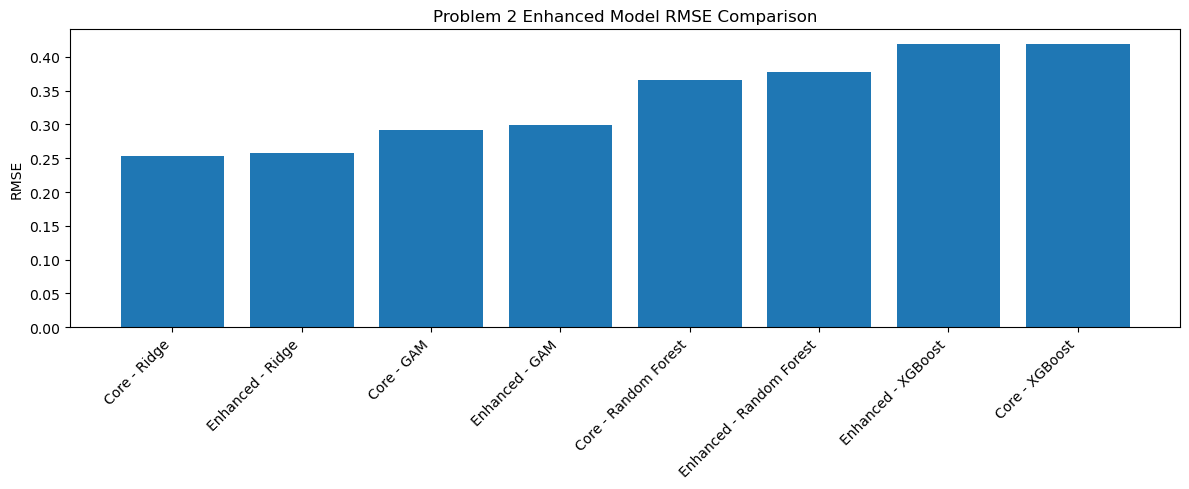

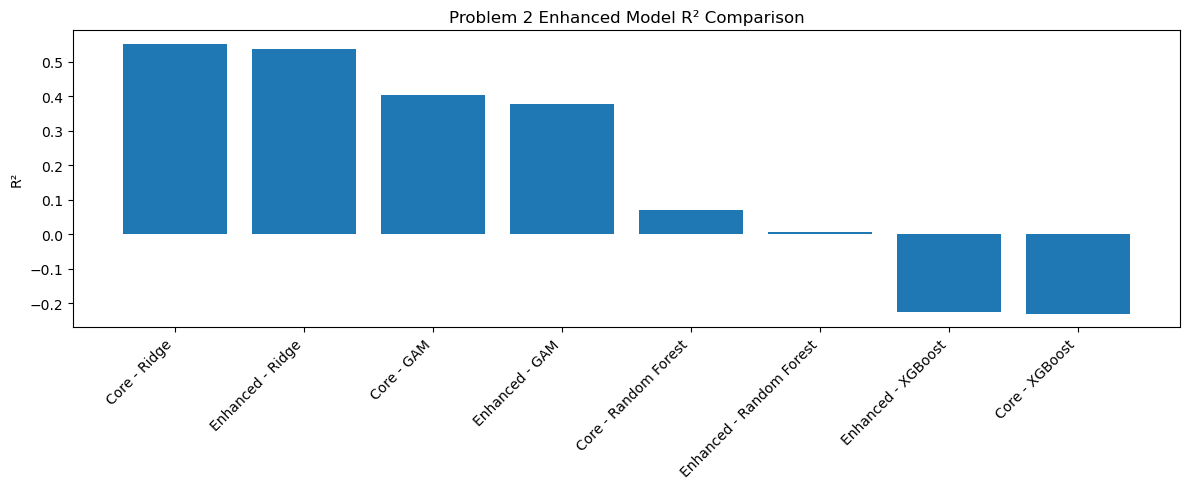

RMSE 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\figures\problem2_enhanced_model_rmse_comparison.png
R² 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\figures\problem2_enhanced_model_r2_comparison.png


In [15]:
plot_results = results_df.copy()
plot_results["label"] = plot_results["feature_set"] + " - " + plot_results["model"]

plt.figure(figsize=(12, 5))
plt.bar(plot_results["label"], plot_results["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Problem 2 Enhanced Model RMSE Comparison")
plt.tight_layout()

rmse_fig_path = FIG_DIR / "problem2_enhanced_model_rmse_comparison.png"
plt.savefig(rmse_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(plot_results["label"], plot_results["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Problem 2 Enhanced Model R² Comparison")
plt.tight_layout()

r2_fig_path = FIG_DIR / "problem2_enhanced_model_r2_comparison.png"
plt.savefig(r2_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("RMSE 图已保存：", rmse_fig_path)
print("R² 图已保存：", r2_fig_path)


## 16. 可视化：最佳模型测试集预测曲线

根据 RMSE 自动选择最佳模型，绘制：

```text
实际 FILT. NTU vs 预测 FILT. NTU
```

输出：

```text
figures/problem2_enhanced_best_model_test_timeseries.png
figures/problem2_enhanced_best_model_actual_vs_predicted.png
figures/problem2_enhanced_best_model_residuals.png
```


最佳模型：


,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,Core,Ridge,73,3821,1639,0.079391,0.253307,0.552146,76.259326


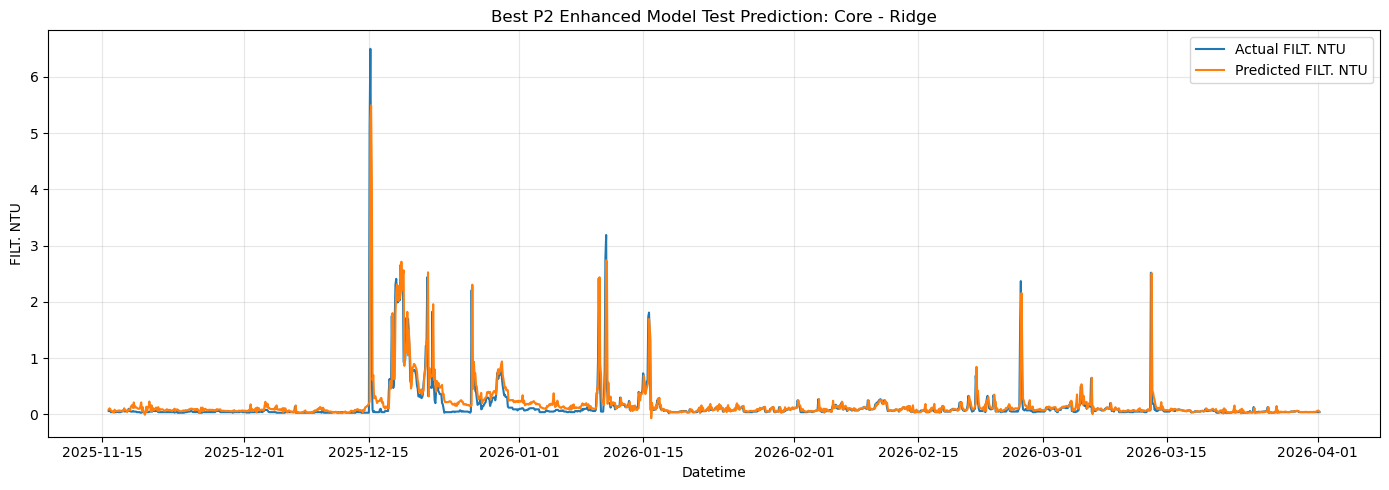

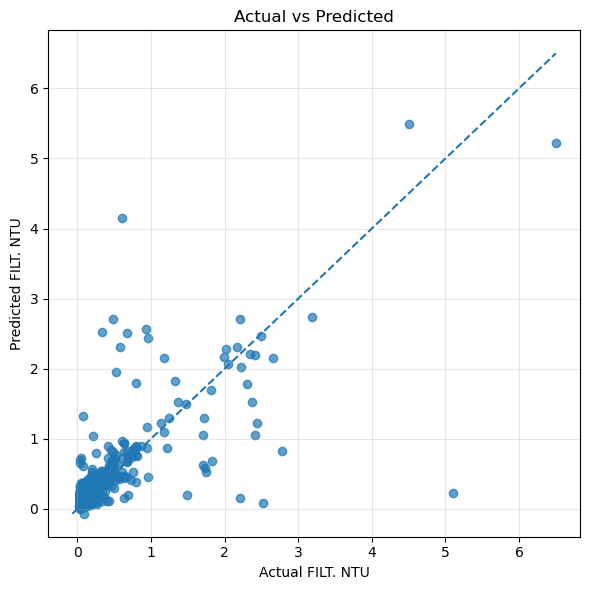

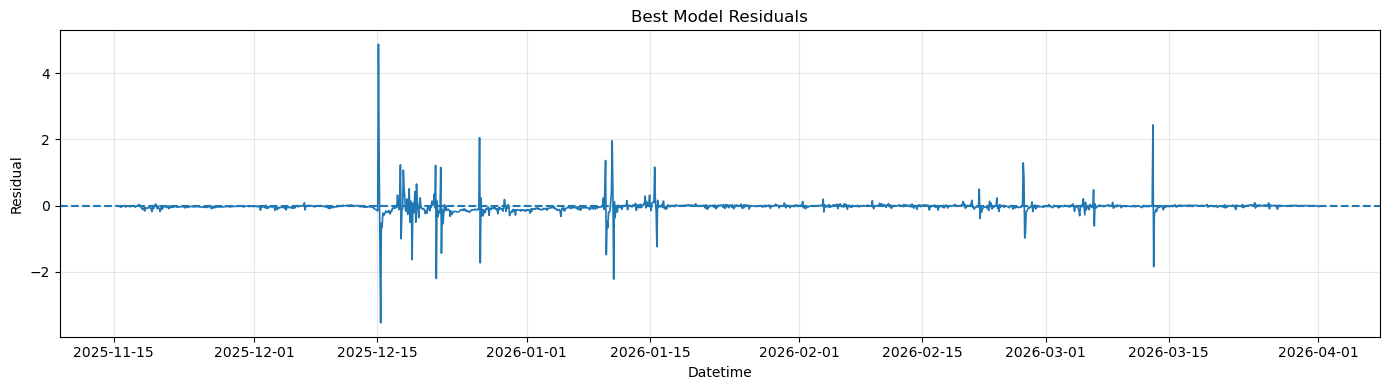

最佳模型预测曲线已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\figures\problem2_enhanced_best_model_test_timeseries.png
实际-预测散点图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\figures\problem2_enhanced_best_model_actual_vs_predicted.png
残差图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\figures\problem2_enhanced_best_model_residuals.png


In [16]:
best_row = results_df.iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]

best_pred_df = predictions_df[
    (predictions_df["feature_set"] == best_feature_set) &
    (predictions_df["model"] == best_model_name)
].copy()

print("最佳模型：")
display(best_row.to_frame().T)

plt.figure(figsize=(14, 5))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["target_FILT_NTU"],
    label="Actual FILT. NTU",
    linewidth=1.5,
)
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["predicted_FILT_NTU"],
    label="Predicted FILT. NTU",
    linewidth=1.5,
)
plt.title(f"Best P2 Enhanced Model Test Prediction: {best_feature_set} - {best_model_name}")
plt.xlabel("Datetime")
plt.ylabel("FILT. NTU")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

best_ts_fig_path = FIG_DIR / "problem2_enhanced_best_model_test_timeseries.png"
plt.savefig(best_ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(
    best_pred_df["target_FILT_NTU"],
    best_pred_df["predicted_FILT_NTU"],
    alpha=0.7,
)
min_val = min(best_pred_df["target_FILT_NTU"].min(), best_pred_df["predicted_FILT_NTU"].min())
max_val = max(best_pred_df["target_FILT_NTU"].max(), best_pred_df["predicted_FILT_NTU"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual FILT. NTU")
plt.ylabel("Predicted FILT. NTU")
plt.title("Actual vs Predicted")
plt.grid(alpha=0.3)
plt.tight_layout()

avp_fig_path = FIG_DIR / "problem2_enhanced_best_model_actual_vs_predicted.png"
plt.savefig(avp_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["residual"],
    linewidth=1.2,
)
plt.axhline(0, linestyle="--")
plt.title("Best Model Residuals")
plt.xlabel("Datetime")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.tight_layout()

residual_fig_path = FIG_DIR / "problem2_enhanced_best_model_residuals.png"
plt.savefig(residual_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("最佳模型预测曲线已保存：", best_ts_fig_path)
print("实际-预测散点图已保存：", avp_fig_path)
print("残差图已保存：", residual_fig_path)


## 17. 可视化：最佳树模型特征重要性

如果最佳模型是 Random Forest 或 XGBoost，则绘制其前 20 个特征重要性。  
如果最佳模型不是树模型，则绘制当前所有树模型中 RMSE 最好的树模型。


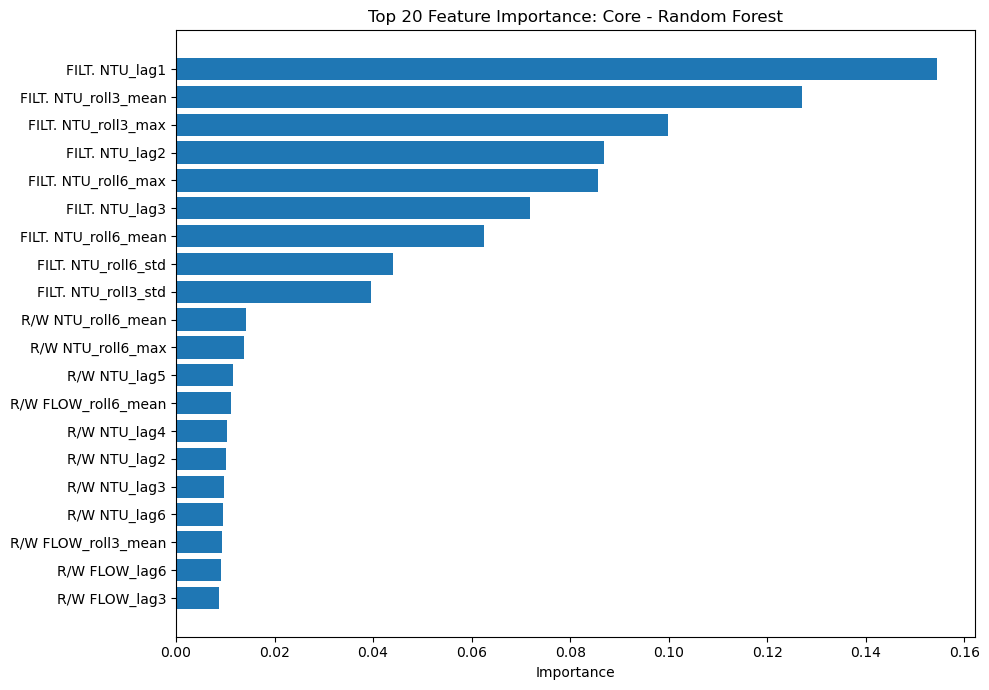

特征重要性图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\figures\problem2_enhanced_top20_feature_importance.png


,feature_set,model,feature,importance,rank
0,Core,Random Forest,FILT. NTU_lag1,0.154422,1
1,Core,Random Forest,FILT. NTU_roll3_mean,0.127027,2
2,Core,Random Forest,FILT. NTU_roll3_max,0.099915,3
3,Core,Random Forest,FILT. NTU_lag2,0.086791,4
4,Core,Random Forest,FILT. NTU_roll6_max,0.085700,5
5,Core,Random Forest,FILT. NTU_lag3,0.071823,6
6,Core,Random Forest,FILT. NTU_roll6_mean,0.062561,7
7,Core,Random Forest,FILT. NTU_roll6_std,0.043963,8
8,Core,Random Forest,FILT. NTU_roll3_std,0.039532,9
9,Core,Random Forest,R/W NTU_roll6_mean,0.014113,10


In [17]:
tree_results = results_df[results_df["model"].isin(["Random Forest", "XGBoost"])].copy()

if len(tree_results) > 0 and len(importance_df) > 0:
    best_tree_row = tree_results.iloc[0]
    best_tree_feature_set = best_tree_row["feature_set"]
    best_tree_model = best_tree_row["model"]

    top_importance = importance_df[
        (importance_df["feature_set"] == best_tree_feature_set) &
        (importance_df["model"] == best_tree_model)
    ].sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    plt.barh(
        top_importance["feature"][::-1],
        top_importance["importance"][::-1],
    )
    plt.xlabel("Importance")
    plt.title(f"Top 20 Feature Importance: {best_tree_feature_set} - {best_tree_model}")
    plt.tight_layout()

    fi_fig_path = FIG_DIR / "problem2_enhanced_top20_feature_importance.png"
    plt.savefig(fi_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("特征重要性图已保存：", fi_fig_path)
    display(top_importance)
else:
    print("没有可用树模型特征重要性，跳过绘图。")


## 18. 输出最终推荐模型摘要

根据 RMSE 最小原则选择最终模型。

输出：

```text
problem2_enhanced_final_summary.xlsx
```


In [18]:
final_summary = pd.DataFrame([
    {
        "item": "target",
        "value": "FILT. NTU",
    },
    {
        "item": "best_feature_set",
        "value": best_feature_set,
    },
    {
        "item": "best_model",
        "value": best_model_name,
    },
    {
        "item": "best_MAE",
        "value": best_row["MAE"],
    },
    {
        "item": "best_RMSE",
        "value": best_row["RMSE"],
    },
    {
        "item": "best_R2",
        "value": best_row["R2"],
    },
    {
        "item": "enhancement_1",
        "value": "Added autoregressive FILT. NTU lag1-lag3.",
    },
    {
        "item": "enhancement_2",
        "value": "Used lag-window features for core variables instead of selected-one-lag.",
    },
    {
        "item": "enhancement_3",
        "value": "Added rolling mean/max/std features to capture short-term accumulation and fluctuation.",
    },
    {
        "item": "enhancement_4",
        "value": "Compared Core features with Enhanced features including auxiliary raw-water and pump-state variables.",
    },
])

final_summary_path = OUTPUT_DIR / "problem2_enhanced_final_summary.xlsx"
final_summary.to_excel(final_summary_path, index=False)

print("最终摘要已保存：", final_summary_path)
display(final_summary)


最终摘要已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_final_summary.xlsx


,item,value
0,target,FILT. NTU
1,best_feature_set,Core
2,best_model,Ridge
3,best_MAE,0.079391
4,best_RMSE,0.253307
5,best_R2,0.552146
6,enhancement_1,Added autoregressive FILT. NTU lag1-lag3.
7,enhancement_2,Used lag-window features for core variables in...
8,enhancement_3,Added rolling mean/max/std features to capture...
9,enhancement_4,Compared Core features with Enhanced features ...


## 19. 论文中可以使用的文字说明

可以在论文第二题中写：

```text
初始 selected-lag 模型仅为每个输入变量选择单一最佳时滞，但其测试集 R² 较低，说明滤后水浊度受动态惯性、短期累积效应和多变量交互共同影响。为进一步刻画该过程，本文构建增强型动态模型，引入 FILT. NTU 自回归历史项、多滞后窗口特征、短期滚动统计特征，并进一步比较核心变量模型和辅助变量增强模型。
```

对应英文：

```text
The initial selected-lag model retained only one optimal lag for each input variable, but its test R² was limited. This indicates that filtered water turbidity is affected by dynamic persistence, short-term cumulative effects, and multivariable interactions. Therefore, an enhanced dynamic model was developed by incorporating autoregressive FILT. NTU terms, lag-window features, rolling statistics, and auxiliary raw-water state variables.
```


In [19]:
print("=" * 80)
print("问题二 Enhanced Dynamic Model 已完成。")
print("=" * 80)

print("\n核心输出文件：")
print("1. 数据审计：", audit_path)
print("2. 特征说明：", feature_summary_path)
print("3. 建模数据：", model_data_path)
print("4. 模型结果：", results_path)
print("5. 测试集预测：", predictions_path)
print("6. Ridge 参数：", ridge_coef_path)
print("7. 特征重要性：", importance_path)
print("8. 最终摘要：", final_summary_path)
print("9. 模型目录：", MODEL_DIR)
print("10. 图片目录：", FIG_DIR)

print("\n模型结果：")
display(results_df)

print("\n最佳模型：")
display(best_row.to_frame().T)


问题二 Enhanced Dynamic Model 已完成。

核心输出文件：
1. 数据审计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_data_audit.xlsx
2. 特征说明： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_feature_set_summary.xlsx
3. 建模数据： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_model_data.xlsx
4. 模型结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_model_results.xlsx
5. 测试集预测： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_test_predictions.xlsx
6. Ridge 参数： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_ridge_coefficients.xlsx
7. 特征重要性： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_feature_importance.xlsx
8. 最终摘要： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_final_summary.xlsx
9. 模型目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\models
10. 图片目录： E:\桌面\亚太杯\2026-Asia-Pasi

,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,Core,Ridge,73,3821,1639,0.079391,0.253307,0.552146,76.259326
1,Enhanced,Ridge,112,3821,1639,0.087538,0.257289,0.537957,90.896459
2,Core,GAM,73,3821,1639,0.102171,0.292213,0.404008,112.621710
3,Enhanced,GAM,112,3821,1639,0.107178,0.298482,0.378162,120.924069
4,Core,Random Forest,73,3821,1639,0.097384,0.365100,0.069612,70.198428
5,Enhanced,Random Forest,112,3821,1639,0.118430,0.376950,0.008238,126.395135
6,Enhanced,XGBoost,112,3821,1639,0.115884,0.419048,-0.225653,101.644228
7,Core,XGBoost,73,3821,1639,0.103902,0.419739,-0.229703,66.709631



最佳模型：


,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,Core,Ridge,73,3821,1639,0.079391,0.253307,0.552146,76.259326
